# Naive model -- NO2

Baseline: predicts yesterday's value (`lag_1`) unchanged, no training. Runs
top-to-bottom fast on purpose -- this is the sanity check every other model
has to beat.

In [1]:
import matplotlib.pyplot as plt

from src.ml.evaluate import last_fold_predictions, walk_forward_evaluate
from src.ml.models.sklearn_models import NaiveModel
from src.ml.promote import _variable_config

In [2]:
variable = "NO2"
ano = 2024
air_path = "data/silver/aire/all.parquet"
traffic_path = "data/silver/trafico/all.parquet"
runs_dir = "data/gold/ml_runs"

In [3]:
df, target_col, feature_cols, partition_col = _variable_config(
    variable, air_path, traffic_path
)
df.shape

(15811, 10)

## EDA -- distribution and time series of the target

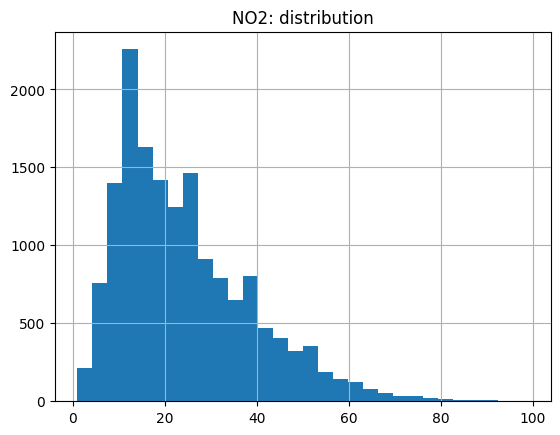

In [4]:
df[target_col].hist(bins=30)
plt.title(f"{variable}: distribution")
plt.show()

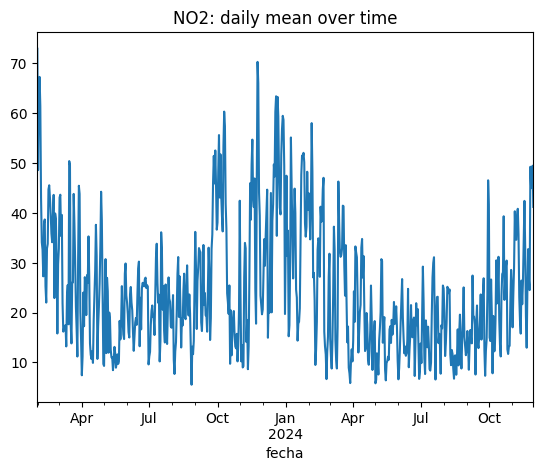

In [5]:
df.groupby("fecha")[target_col].mean().plot()
plt.title(f"{variable}: daily mean over time")
plt.show()

## Model -- naive has no hyperparameters, nothing to tune here.

In [6]:
model = NaiveModel()

## Walk-forward evaluation + held-out real vs. predicted

In [7]:
comparison = walk_forward_evaluate([model], df, target_col, feature_cols)
comparison

,model,mae,rmse,mape
0,naive,7.112939,9.536814,0.378691


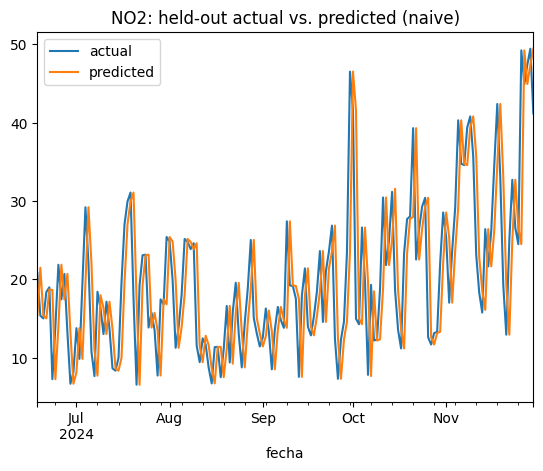

In [8]:
holdout = last_fold_predictions(
    model.__class__(), df, target_col, feature_cols, partition_col
)
holdout.groupby("fecha")[["actual", "predicted"]].mean().plot()
plt.title(f"{variable}: held-out actual vs. predicted ({model.name})")
plt.show()

## Write this model's run -- never touches `gold/ml_<variable>_<ano>.*`
directly, only `promote.promote_winner` does that.

In [9]:
from pathlib import Path  # noqa: E402

Path(runs_dir).mkdir(parents=True, exist_ok=True)
out = Path(runs_dir) / f"{variable}_{model.name}_{ano}.parquet"
comparison.to_parquet(out)
out

WindowsPath('data/gold/ml_runs/NO2_naive_2024.parquet')